# Sanity checks on the imagery dates, and on the correction

Two parts. The first checks the output of the dating step before anything downstream relies on it.
The second inspects the corrected capacities: how much the correction moves each unit, and in which
direction.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# `helpers` is imported for its figure utilities only: the export helper, the
# basemap and the axis chrome. The dependency is on presentation, not on the
# calibration logic, so no result in this notebook depends on the evaluation step.
import sys
from pathlib import Path


def _find_root(start=None, marker='paths.py'):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"{marker} introuvable en remontant depuis {p}")


ROOT = _find_root()
sys.path.insert(0, str(ROOT))
import paths
sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src'))
import helpers
import style
style.apply()

FIGS_DIR = paths.FIGURES

In [2]:
communes = gpd.read_file(paths.IMAGERY_DATES)
communes["imagedate"] = pd.to_datetime(communes["imagedate"])
print(communes.shape)
communes.head()

(32604, 9)


,insee,nom,dpt,dpt_source,n_installations,kWp_total,year_median,imagedate,geometry
0,01001,L'Abergement-Clémenciat,01,001,25,91.41,2024.0,2024-08-12,POINT (4.92508 46.14569)
1,01002,L'Abergement-de-Varey,01,001,5,16.38,2024.0,2024-08-13,POINT (5.42283 46.01201)
2,01004,Ambérieu-en-Bugey,01,001,152,676.40,2024.0,2024-08-13,POINT (5.3579 45.95865)
3,01005,Ambérieux-en-Dombes,01,001,37,168.89,2024.0,2024-08-12,POINT (4.90877 45.99664)
4,01006,Ambléon,01,001,1,4.59,2024.0,2024-08-06,POINT (5.60093 45.74659)


## 1. Dates

### 1.1 Valeurs manquantes

In [3]:
n_missing = communes["imagedate"].isna().sum()
print(f"{n_missing} municipalities without a date, out of {len(communes)} ({n_missing / len(communes):.2%})")

communes[communes["imagedate"].isna()][["insee", "nom", "dpt", "n_installations"]]

0 municipalities without a date, out of 32604 (0.00%)


,insee,nom,dpt,n_installations


### 1.2 Plage de dates et valeurs aberrantes

In [4]:
print("min:", communes["imagedate"].min())
print("max:", communes["imagedate"].max())

# Plausibility bounds for an aerial survey date
DATE_MIN = pd.Timestamp("2000-01-01")
date_max_ok = pd.Timestamp.today()

outliers = communes[
    communes["imagedate"].notna()
    & ((communes["imagedate"] < DATE_MIN) | (communes["imagedate"] > date_max_ok))
]
print(f"{len(outliers)} dates outside the plausible range [{DATE_MIN.date()}, {date_max_ok.date()}]")
outliers[["insee", "nom", "dpt", "imagedate"]]

min: 2022-06-29 00:00:00
max: 2025-08-30 00:00:00
0 dates outside the plausible range [2000-01-01, 2026-08-13]


,insee,nom,dpt,imagedate


### 1.3 Distribution of the survey dates

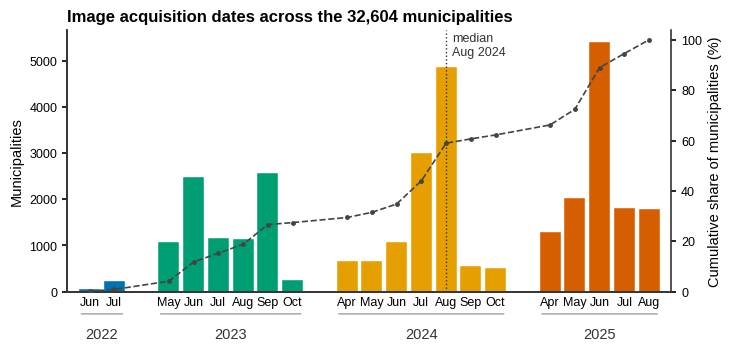

In [5]:
GAP = 1.2   # gap, in bar widths, inserted between two annual campaigns
style.apply(fig_width_in=7.2)

monthly = communes['imagedate'].dt.to_period('M').value_counts().sort_index()
months = monthly.index.to_timestamp()
counts = monthly.to_numpy()
years = months.year.to_numpy()
cum = np.cumsum(counts) / counts.sum()
median_date = communes['imagedate'].median()

# The x axis is BROKEN: only the months actually acquired take a position.
# Survey campaigns are seasonal, so on a continuous time axis half the width goes
# to empty months and squeezes the ones carrying the information.
pos, year_spans, x = [], {}, 0.0
for i, y in enumerate(years):
    if i and y != years[i - 1]:
        x += GAP
    pos.append(x)
    year_spans.setdefault(y, [x, x])[1] = x
    x += 1.0
pos = np.array(pos)

YEAR_COLORS = [style.OKABE_ITO[k] for k in
               ('blue', 'bluish_green', 'orange', 'vermillion', 'reddish_purple', 'sky_blue')]
uy = sorted(year_spans)
cmap = {y: YEAR_COLORS[i % len(YEAR_COLORS)] for i, y in enumerate(uy)}

fig, ax = plt.subplots(figsize=(7.2, 3.4), layout='constrained')
ax.bar(pos, counts, width=0.85, color=[cmap[y] for y in years],
       edgecolor='white', linewidth=0.3, zorder=2)

# The cumulative curve is what says when the territory was covered, which the
# monthly distribution alone does not.
ax2 = ax.twinx()
ax2.plot(pos, cum * 100, color='#444444', lw=1.2, ls='--', marker='o', ms=2.5, zorder=3)
ax2.set_ylim(0, 104)
ax2.set_ylabel('Cumulative share of municipalities (%)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color('#333333')

med_period = median_date.to_period('M').to_timestamp()
i_med = int(np.searchsorted(months, med_period))
ax.axvline(pos[i_med], color='#333333', lw=1.0, ls=':', zorder=4)
ax.annotate(f"median\n{median_date:%b %Y}", (pos[i_med], ax.get_ylim()[1]),
            xytext=(4, -2), textcoords='offset points', va='top', ha='left',
            fontsize=style.FONT_SIZE_SMALL, color='#333333')

ax.set_xticks(pos)
ax.set_xticklabels([m.strftime('%b') for m in months], fontsize=style.FONT_SIZE_SMALL)
ax.set_xlim(pos[0] - 0.9, pos[-1] + 0.9)
ax.set_ylabel('Municipalities')
ax.set_xlabel('')
ax.tick_params(axis='x', length=0)

# Year under each group with a span rule, standing in for the continuous time axis
for y, (x0, x1) in year_spans.items():
    ax.annotate('', xy=(x0 - 0.45, -0.085), xytext=(x1 + 0.45, -0.085),
                xycoords=('data', 'axes fraction'), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='-', color='#888888', lw=0.8))
    ax.annotate(str(y), ((x0 + x1) / 2, -0.135), xycoords=('data', 'axes fraction'),
                ha='center', va='top', fontsize=style.FONT_SIZE_BODY, color='#333333')

ax.set_title(f'Image acquisition dates across the {len(communes):,} municipalities',
             fontweight='bold', fontsize=style.FONT_SIZE_PANEL_LABEL, loc='left')

helpers.save_fig(fig, 'image_acquisition_dates.pdf', FIGS_DIR)
plt.show()

### 1.4 Consistency with the median installation year

The survey must be at or after the median installation year of the detections in that municipality.
An installation cannot appear on a photograph taken before it was built, so a violation here is a
dating error rather than a curiosity.

In [6]:
if "year_median" not in communes.columns:
    print("year_median column missing -- regenerate the dates file with the current datation.py")
else:
    incoherent = communes[
        communes["imagedate"].notna()
        & (communes["imagedate"].dt.year != communes["year_median"])
    ]
    print(f"{len(incoherent)} municipalities where the survey year differs from the median installation year")
incoherent[["insee", "nom", "dpt", "imagedate", "year_median"]]

0 municipalities where the survey year differs from the median installation year


,insee,nom,dpt,imagedate,year_median


### 1.5 Summary

In [7]:
print("─" * 50)
print("Sanity check summary: dates")
print(f"  municipalities          : {len(communes)}")
print(f"  missing dates           : {n_missing}")
print(f"  dates out of range      : {len(outliers)}")
if "year_median" in communes.columns:
    print(f"  inconsistent dates      : {len(incoherent)}")

──────────────────────────────────────────────────
Sanity check summary: dates
  municipalities          : 32604
  missing dates           : 0
  dates out of range      : 0
  inconsistent dates      : 0


### 1.6 Map of the survey year

In [8]:
# The published version of this map is produced by dates/dates_visualisation.ipynb.

## 2. The correction

The output of `recalibration/recalibrate.py`: installed capacity and installation counts per unit,
corrected by a Monte-Carlo bootstrap of the precision-over-recall factor.

The annotation effort was closed before this correction was produced, so the uncertainties shown
here are final rather than provisional.

### 2.1 Chargement

In [9]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('recalibration').resolve()))
import bootstrap

RECALIBRATION_FILE = Path(paths.RECALIBRATION)
CALIBRATION_FILE = Path(paths.EVAL_TABLE)

assert RECALIBRATION_FILE.exists(), (
    f"{RECALIBRATION_FILE} introuvable -- lancer recalibration/recalibrate.py d'abord "
    f"(cd recalibration && python recalibrate.py)"
)

recal = gpd.read_file(RECALIBRATION_FILE)
calibration = pd.read_csv(CALIBRATION_FILE, dtype={'dpt': str})
print(f"{len(recal)} departements charges")
recal.head()

93 departements charges


,dpt,nom,n_inst_raw,p_inst_raw,n_inst_mean,n_inst_ci95_low,n_inst_ci95_high,n_inst_ci99_low,n_inst_ci99_high,p_inst_mean,p_inst_ci95_low,p_inst_ci95_high,p_inst_ci99_low,p_inst_ci99_high,geometry
0,01,Ain,10978,47193.74,15883.199027,14020.975920,18221.924931,13524.875134,19236.092415,68280.885885,60275.304437,78334.923255,58142.597978,82694.766264,"POLYGON ((4.79609 46.13912, 4.8029 46.15612, 4..."
1,02,Aisne,2728,14665.55,3857.672261,3206.009866,4691.696334,3065.605905,5024.889037,20738.594363,17235.299852,25222.253361,16480.497319,27013.475595,"POLYGON ((3.74876 49.15864, 3.70289 49.14147, ..."
2,03,Allier,4421,22475.08,7204.424972,5863.955394,8964.787871,5539.919979,9694.321705,36625.204160,29810.646144,45574.377875,28163.344204,49283.116009,"POLYGON ((3.12956 46.72743, 3.16612 46.69138, ..."
3,04,Alpes-de-Haute-Provence,3998,19451.22,6066.991532,5239.679039,7141.500668,5041.575824,7555.520951,29517.355432,25492.283569,34745.097703,24528.464357,36759.404759,"POLYGON ((6.78162 43.88355, 6.74881 43.87164, ..."
4,05,Hautes-Alpes,3151,17432.44,4802.021309,4152.137487,5627.354369,3989.840160,6006.028849,26566.470438,22971.084611,31132.503141,22073.198730,33227.463521,"POLYGON ((5.6727 44.24561, 5.67438 44.25691, 5..."


In [10]:
recal['n_inst_mean'].sum()

np.float64(822980.7103149672)

### 2.2 Capacity before and after correction

Two separate tables, for units corrected upward and downward. The split is not cosmetic: upward
means the detector misses more than it invents, downward the reverse, and the direction of the bias
is a different fact from its size.

In [11]:
delta = recal[['dpt', 'nom', 'p_inst_raw', 'p_inst_mean', 'p_inst_ci95_low', 'p_inst_ci95_high']].copy()
delta['delta'] = delta['p_inst_mean'] - delta['p_inst_raw']
delta['delta_pct'] = delta['delta'] / delta['p_inst_raw']

print(f"national raw       : {delta['p_inst_raw'].sum():,.0f} kWp")
print(f"national corrected : {delta['p_inst_mean'].sum():,.0f} kWp "
      f"({delta['delta'].sum():+,.0f} kWp, {delta['delta'].sum() / delta['p_inst_raw'].sum():+.1%})")
print(f"{(delta['delta'] > 0).sum()} unit(s) corrected upward, "
      f"{(delta['delta'] < 0).sum()} downward")

national raw       : 2,903,884 kWp
national corrected : 4,033,003 kWp (+1,129,120 kWp, +38.9%)
91 unit(s) corrected upward, 2 downward


In [12]:
hausse = delta[delta['delta'] > 0].sort_values('delta_pct', ascending=False)
print(f"corrected UPWARD ({len(hausse)} units):")
hausse[['dpt', 'nom', 'p_inst_raw', 'p_inst_mean', 'delta', 'delta_pct']]

corrected UPWARD (91 units):


,dpt,nom,p_inst_raw,p_inst_mean,delta,delta_pct
79,79,Deux-Sèvres,32294.96,67663.735644,35368.775644,1.095179
48,48,Lozère,7916.29,16111.600442,8195.310442,1.035246
28,2A,Corse-du-Sud,6836.16,13081.375837,6245.215837,0.913556
22,24,Dordogne,29501.90,52586.608353,23084.708353,0.782482
59,59,Nord,47037.46,82875.948223,35838.488223,0.761914
...,...,...,...,...,...,...
11,12,Aveyron,40720.74,42458.664061,1737.924061,0.042679
89,89,Yonne,8377.31,8610.512603,233.202603,0.027837
53,53,Mayenne,32869.94,33717.022858,847.082858,0.025771
54,54,Meurthe-et-Moselle,30863.96,31621.278653,757.318653,0.024537


In [13]:
baisse = delta[delta['delta'] < 0].sort_values('delta_pct')
print(f"corrected DOWNWARD ({len(baisse)} units):")
baisse[['dpt', 'nom', 'p_inst_raw', 'p_inst_mean', 'delta', 'delta_pct']]

corrected DOWNWARD (2 units):


,dpt,nom,p_inst_raw,p_inst_mean,delta,delta_pct
25,27,Eure,22037.17,20894.074662,-1143.095338,-0.051871
75,75PC,Paris + petite couronne,35652.99,34528.101528,-1124.888472,-0.031551


### 2.3 Posteriors for a selection of units

Regenerated through the shared module, with the same Beta parameters as the main chain and the same
deterministic seed. The histogram is therefore exactly the distribution the correction output
summarises, not a re-derivation that could drift.

In [14]:
import sys
from pathlib import Path

def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)

sys.path.insert(0, str(_find_root(Path.cwd())))
import paths
import dept_posteriors as dp

SELECTED_DEPTS = ['69', '34', '50']  # adjust to illustrate other units

calibration_table = pd.read_csv(paths.EVAL_TABLE, dtype={'dpt': str})
draws_by_dept = dp.compute_dept_draws(SELECTED_DEPTS, calibration_table, recal)


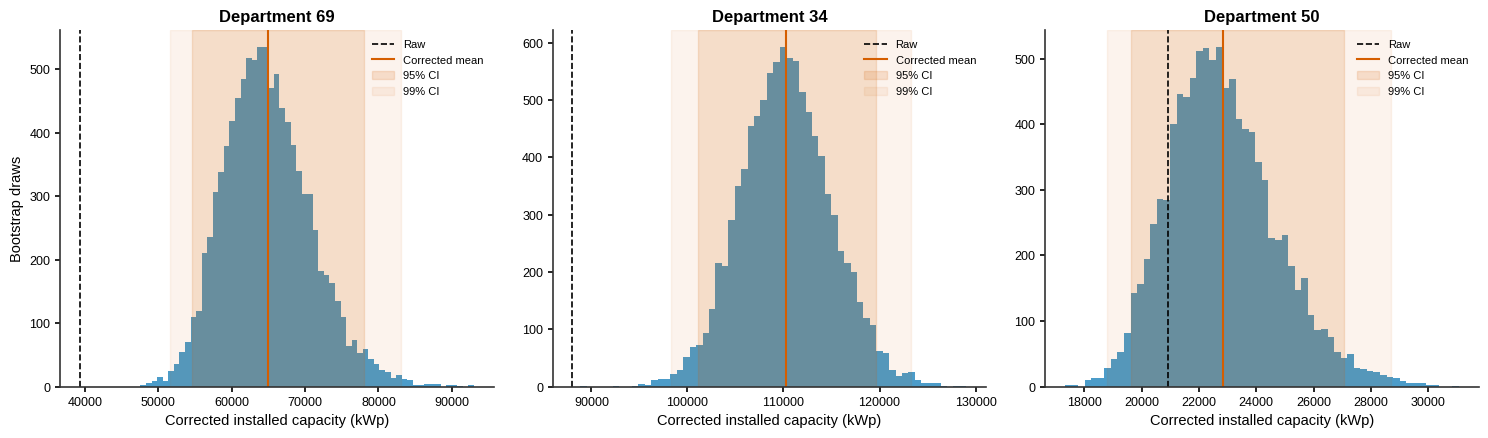

In [15]:
fig = dp.plot_depts(draws_by_dept, quantity='p_inst')
plt.savefig(paths.FIGURES / 'examples_posterior_distributions.pdf')
plt.show()


### 2.4 Map: corrected capacity, and the direction of the correction

Two panels on the same geometry. On the left the magnitude, on the right the direction, diverging
around zero, so that where the detector under-detects and where it over-detects can be read at a
glance.

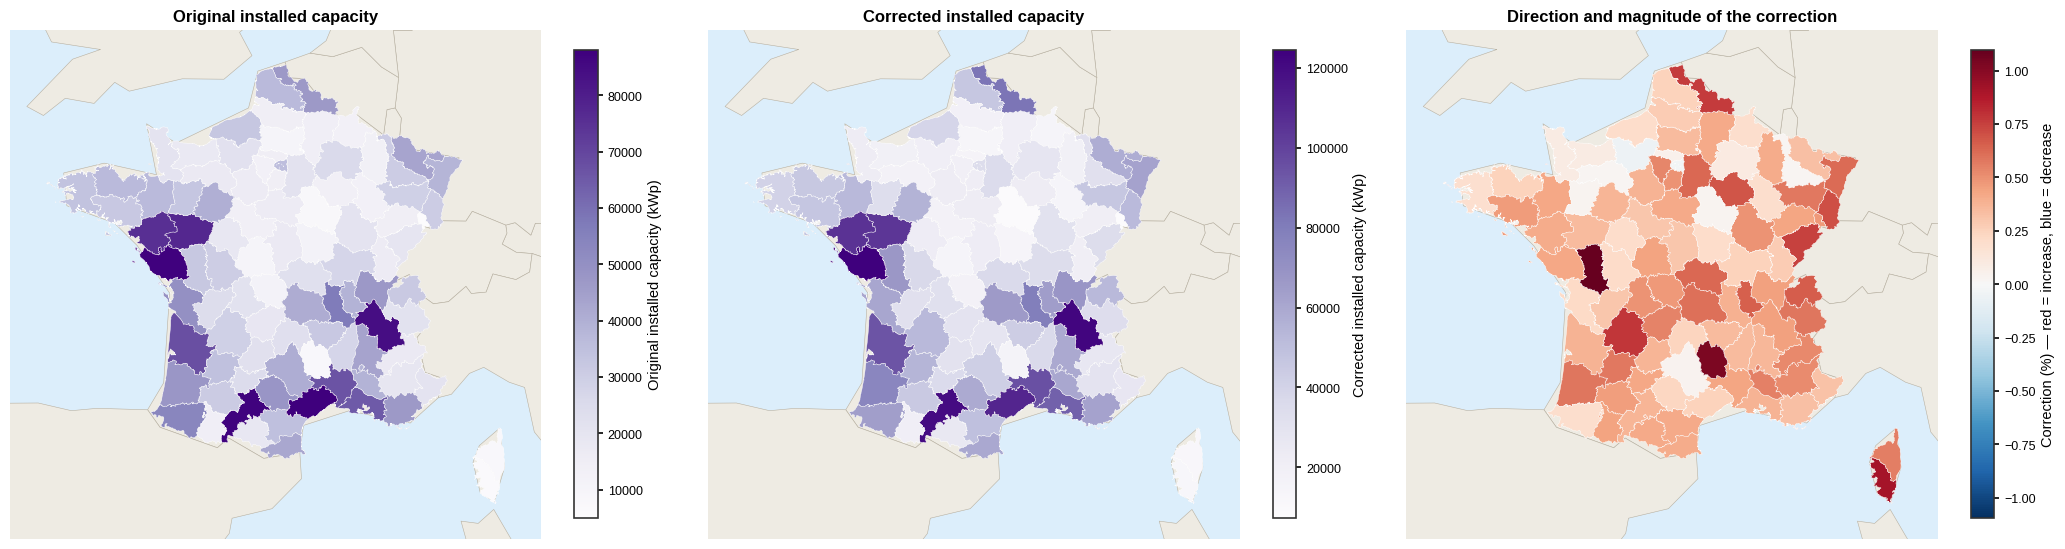

In [16]:
import matplotlib.colors as mcolors


WORLD_LOWRES_FILE = Path(paths.WORLD)
world = gpd.read_file(WORLD_LOWRES_FILE)


def add_basemap(
    ax,
    bounds,
    margin=0.08,
    land_color=style.BASEMAP_LAND,
    sea_color=style.BASEMAP_SEA,
    edge_color=style.BASEMAP_EDGE,
):
    ax.set_facecolor(sea_color)
    world.plot(
        ax=ax,
        color=land_color,
        edgecolor=edge_color,
        linewidth=0.4,
        zorder=0,
    )

    xmin, ymin, xmax, ymax = bounds
    dx = (xmax - xmin) * margin
    dy = (ymax - ymin) * margin

    ax.set_xlim(xmin - dx, xmax + dx)
    ax.set_ylim(ymin - dy, ymax + dy)


def hide_axis_chrome(ax):
    # Do not use ax.axis("off") / set_axis_off(), as this also
    # disables the sea background from add_basemap().
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


recal_map = recal.copy()

# Percentage correction
recal_map["delta_pct"] = (
    recal_map["p_inst_mean"] - recal_map["p_inst_raw"]
) / recal_map["p_inst_raw"]

bounds = recal_map.total_bounds


fig, axes = plt.subplots(1,3,figsize=(21, 7))


# ------------------------------------------------------------------
# 0. Original installed capacity
# ------------------------------------------------------------------

add_basemap(axes[0], bounds)

recal_map.plot(
    column="p_inst_raw",
    cmap=style.CMAP_MAGNITUDE,
    legend=True,
    ax=axes[0],
    edgecolor="white",
    linewidth=0.3,
    zorder=1,
    legend_kwds={
        "label": "Original installed capacity (kWp)",
        "shrink": 0.7,
    },
)

axes[0].set_title(
    "Original installed capacity",
    fontweight="bold",
)

hide_axis_chrome(axes[0])


# ------------------------------------------------------------------
# 1. Corrected installed capacity
# ------------------------------------------------------------------

add_basemap(axes[1], bounds)

recal_map.plot(
    column="p_inst_mean",
    cmap=style.CMAP_MAGNITUDE,
    legend=True,
    ax=axes[1],
    edgecolor="white",
    linewidth=0.3,
    zorder=1,
    legend_kwds={
        "label": "Corrected installed capacity (kWp)",
        "shrink": 0.7,
    },
)

axes[1].set_title(
    "Corrected installed capacity",
    fontweight="bold",
)

hide_axis_chrome(axes[1])


# ------------------------------------------------------------------
# 2. Direction and magnitude of the correction
# ------------------------------------------------------------------

vmax = recal_map["delta_pct"].abs().max()

norm = mcolors.TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax,
)

add_basemap(axes[2], bounds)

recal_map.plot(
    column="delta_pct",
    cmap=style.CMAP_DIVERGING,
    norm=norm,
    legend=True,
    ax=axes[2],
    edgecolor="white",
    linewidth=0.3,
    zorder=1,
    legend_kwds={
        "label": "Correction (%) — red = increase, blue = decrease",
        "shrink": 0.7,
    },
)

axes[2].set_title(
    "Direction and magnitude of the correction",
    fontweight="bold",
)

hide_axis_chrome(axes[2])


plt.tight_layout()
plt.savefig(paths.FIGURES / 'plot_regressement_capacity.pdf')
plt.show()

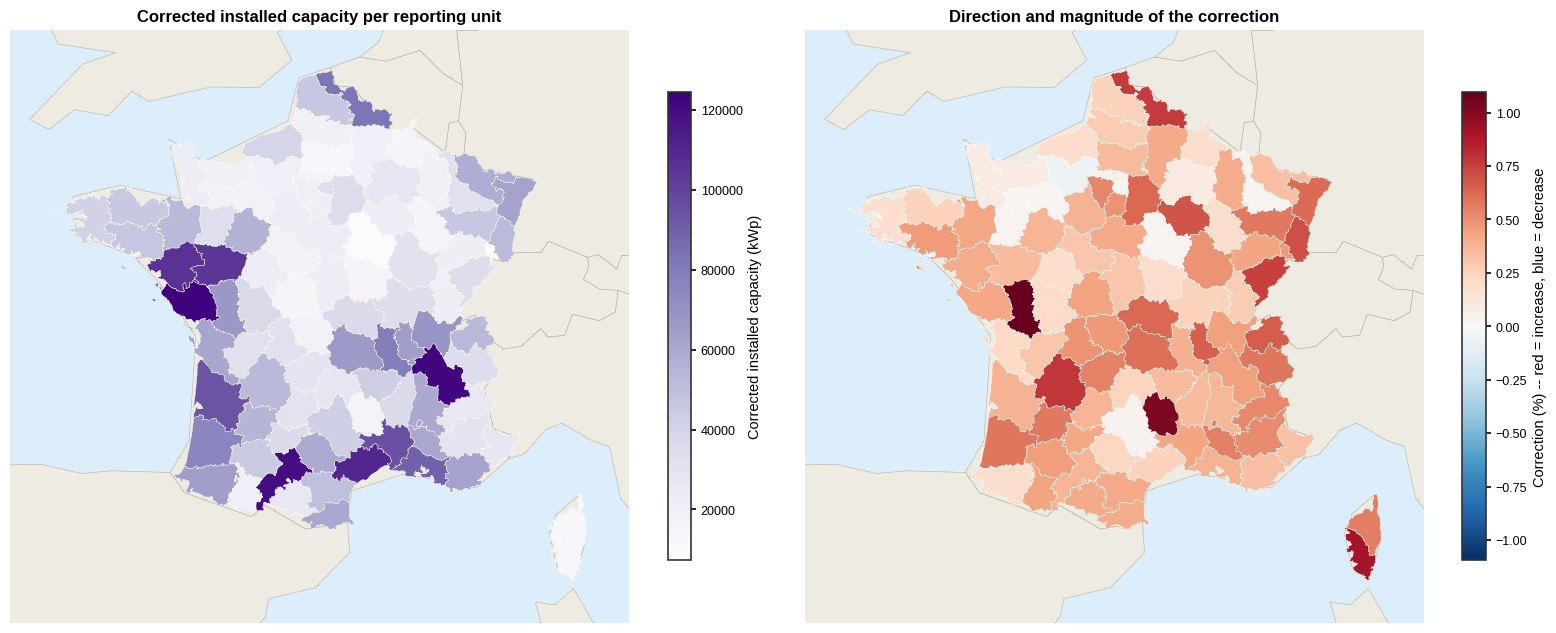

In [17]:
import matplotlib.colors as mcolors

WORLD_LOWRES_FILE = Path(paths.WORLD)  # offline basemap; this pipeline has no tile-server access
world = gpd.read_file(WORLD_LOWRES_FILE)

def add_basemap(ax, bounds, margin=0.08, land_color=style.BASEMAP_LAND, sea_color=style.BASEMAP_SEA, edge_color=style.BASEMAP_EDGE):
    ax.set_facecolor(sea_color)
    world.plot(ax=ax, color=land_color, edgecolor=edge_color, linewidth=0.4, zorder=0)
    xmin, ymin, xmax, ymax = bounds
    dx, dy = (xmax - xmin) * margin, (ymax - ymin) * margin
    ax.set_xlim(xmin - dx, xmax + dx)
    ax.set_ylim(ymin - dy, ymax + dy)

def hide_axis_chrome(ax):
    # NOT ax.axis("off"): that also disables the background patch, erasing the sea
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

recal_map = recal.copy()
recal_map["delta_pct"] = (recal_map["p_inst_mean"] - recal_map["p_inst_raw"]) / recal_map["p_inst_raw"]
bounds = recal_map.total_bounds

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

add_basemap(axes[0], bounds)
recal_map.plot(column="p_inst_mean", cmap=style.CMAP_MAGNITUDE, legend=True, ax=axes[0],
               edgecolor="white", linewidth=0.3, zorder=1,
               legend_kwds={"label": "Corrected installed capacity (kWp)", "shrink": 0.7})
axes[0].set_title("Corrected installed capacity per reporting unit", fontweight="bold")
hide_axis_chrome(axes[0])

vmax = recal_map["delta_pct"].abs().max()
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
add_basemap(axes[1], bounds)
recal_map.plot(column="delta_pct", cmap=style.CMAP_DIVERGING, norm=norm, legend=True, ax=axes[1],
               edgecolor="white", linewidth=0.3, zorder=1,
               legend_kwds={"label": "Correction (%) -- red = increase, blue = decrease", "shrink": 0.7})
axes[1].set_title("Direction and magnitude of the correction", fontweight="bold")
hide_axis_chrome(axes[1])

plt.tight_layout()
plt.savefig(paths.FIGURES / 'plot_regressement_capacity_two_plot.pdf')
plt.show()

In [18]:
n_total_raw = recal['n_inst_raw'].sum()
n_total_redressed = recal['n_inst_mean'].sum()
p_total_raw = recal['p_inst_raw'].sum()
p_total_redressed = recal['p_inst_mean'].sum()

print(f"total installations : {n_total_raw:,.0f} raw -> {n_total_redressed:,.0f} corrected")
print(f"total capacity      : {p_total_raw:,.0f} kWp raw -> {p_total_redressed:,.0f} kWp corrected")
print()
print("Note: this is the sum of the per-unit corrected means, not a bootstrap mean of the")
print("national total. The two need not coincide; see the aggregation-scales notebook.")

total installations : 589,623 raw -> 822,981 corrected
total capacity      : 2,903,884 kWp raw -> 4,033,003 kWp corrected

Note: this is the sum of the per-unit corrected means, not a bootstrap mean of the
national total. The two need not coincide; see the aggregation-scales notebook.


### 2.5 Aggregation scales: moved

This notebook used to compare the national total formed at unit level against a pooled national
factor. That comparison now lives in `code/0_pipeline/sanity_checks/estimation_convergence_scales.ipynb`,
and the move fixed a real problem rather than merely tidying up.

The version here rebuilt the Beta parameters by hand under a Jeffreys prior while the pipeline had
already moved to empirical Bayes. Its totals therefore matched no published figure, and the gap it
displayed between aggregation levels was a prior effect rather than an aggregation effect. The
replacement reads the prior from the calibration table, so it cannot drift out of step again.
